# 04. 개선 모델 평가 (GradientBoosting & XGBoost)

## STEP 0. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## STEP 1. 데이터 로드 및 KR 필터링 (약 2~3분 소요)

In [2]:
import csv

kr_rows = []
filepath = '/Users/eunseoklee/Downloads/ml/trending_yt_videos_113_countries.csv'

with open(filepath, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['country'] == 'KR':
            kr_rows.append(row)

df_raw = pd.DataFrame(kr_rows)
print(f'KR 원본 행 수: {len(df_raw):,}')
df_raw.head()

KR 원본 행 수: 48,341


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,thumbnail_url,video_id,channel_id,video_tags,kind,publish_date,langauge
0,Smile For You,ISEGYE IDOL - Topic,1,49,49,2026-06-20,KR,35209,2581,131,Provided to YouTube by GENIE MUSIC\n\nSmile Fo...,https://i.ytimg.com/vi/IJcbS_dQABk/mqdefault.jpg,IJcbS_dQABk,UChQveKKV7nZHLSGJaAKOkHA,"ISEGYE IDOL, 이세계아이돌, Smile For You",youtube#video,2026-06-19 00:00:00+00:00,ko
1,진짜 떴습니다. ≪스파이더맨: 브랜드뉴데이≫ 메인 예고편 리뷰 & 떡밥 나노 분석 총정리,무비띵크_Movie Think,2,0,48,2026-06-20,KR,624983,9668,1159,#스파이더맨브랜드뉴데이 #스파이더맨 #브랜드뉴데이\n🎬 진짜 떴습니다. ≪스파이더맨...,https://i.ytimg.com/vi/SV7EDrgTmPw/mqdefault.jpg,SV7EDrgTmPw,UCKBzr20577Xcn0LJoRVES_A,"영화리뷰, 영화추천, 무비띵크, 마블, 마블영화, 마블유튜브, 마블유튜버, 마블띵크...",youtube#video,2026-06-18 00:00:00+00:00,ko
2,다딱이 감독관,랄로,3,0,47,2026-06-20,KR,694748,5072,670,랄로 풀코스 youtube.com/@랄롱\n치지직 생방송 https://naver....,https://i.ytimg.com/vi/HLSQWGqAW0Y/mqdefault.jpg,HLSQWGqAW0Y,UCD2YO_A_PVMgMDN9jpRrpVA,"랄로, 랄튜브, 김찬호",youtube#video,2026-06-18 00:00:00+00:00,ko
3,Fast Cars & Superstars,Cristian Marchi - Topic,4,6,46,2026-06-20,KR,110227,1327,0,Provided to YouTube by Universal Music Group\n...,https://i.ytimg.com/vi/l26KDHTABxw/mqdefault.jpg,l26KDHTABxw,UCfc-IfX9K_qr9jBF5lFA9-w,"Cristian Marchi, Reverend Haus, Fast Cars & Su...",youtube#video,2026-06-18 00:00:00+00:00,en
4,[스파이더맨: 브랜드 뉴 데이] 메인 예고편,소니픽쳐스코리아,5,0,45,2026-06-20,KR,1497359,19698,3050,모두가 그를 잊었지만\n세상은 그가 필요하다\n\n[스파이더맨: 브랜드 뉴 데이] ...,https://i.ytimg.com/vi/dosbhD_1LIo/mqdefault.jpg,dosbhD_1LIo,UCY2wHBgv2W30w6lqoLxq99g,,youtube#video,2026-06-17 00:00:00+00:00,en


## STEP 2. 데이터 타입 변환

In [3]:
df = df_raw.copy()

for col in ['view_count','like_count','comment_count','daily_rank','daily_movement','weekly_movement']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])
df['publish_date']  = pd.to_datetime(df['publish_date'], utc=True).dt.tz_localize(None)

print('=== 결측치 현황 ===')
print(df.isnull().sum())

=== 결측치 현황 ===
title              0
channel_name       0
daily_rank         0
daily_movement     0
weekly_movement    0
snapshot_date      0
country            0
view_count         0
like_count         0
comment_count      0
description        0
thumbnail_url      0
video_id           0
channel_id         0
video_tags         0
kind               0
publish_date       0
langauge           0
dtype: int64


## STEP 3. 영상별 집계 (중복 제거)

In [4]:
agg = df.groupby('video_id').agg(
    title         = ('title', 'first'),
    channel_name  = ('channel_name', 'first'),
    view_count    = ('view_count', 'max'),
    like_count    = ('like_count', 'max'),
    comment_count = ('comment_count', 'max'),
    best_rank     = ('daily_rank', 'min'),
    trending_days = ('snapshot_date', 'nunique'),
    first_trend   = ('snapshot_date', 'min'),
    publish_date  = ('publish_date', 'first'),
    video_tags    = ('video_tags', 'first'),
    language      = ('langauge', 'first'),
).reset_index()

print(f'고유 영상 수: {len(agg):,}')
agg.head(3)

고유 영상 수: 19,129


,video_id,title,channel_name,view_count,like_count,comment_count,best_rank,trending_days,first_trend,publish_date,video_tags,language
0,--b0x4XO6_g,"붉은사막 플레이 약 30시간 째, 중간 소감입니다",중년게이머 김실장,172407,3506,1290,17,1,2026-03-27,2026-03-26,,ko
1,-03OtM9D-fU,멕시코 vs 대한민국 - FIFA 월드컵 2026 | 조별리그 | 손흥민 vs 멕시...,Alone Gaming,100509,1604,101,20,1,2026-06-19,2026-06-18,"멕시코, 대한민국, 손흥민, FIFA 월드컵 2026, 조별리그, 멕시코 대한민국 ...",ko
2,-0ICh3CmHVs,[EN/JP] [#WSWF/3회 선공개] 리더 계급 메인 댄서? 뺏어줄게!,The CHOOM (더 춤),1369114,15734,3860,3,3,2025-06-08,2025-06-07,"Dance, Mnet, SWF, SWF3, WorldofSWF, 댄스, 스우파, 스...",en-US


## STEP 4. 파생 변수(Feature Engineering) 생성

In [5]:
agg['title_length']   = agg['title'].str.len()
agg['tag_count']      = agg['video_tags'].apply(
    lambda x: 0 if (pd.isna(x) or x.strip() == '') else len(x.split('|'))
)
agg['like_ratio']     = agg['like_count'] / (agg['view_count'] + 1)
agg['comment_ratio']  = agg['comment_count'] / (agg['view_count'] + 1)
agg['days_to_trend']  = (agg['first_trend'] - agg['publish_date']).dt.days.clip(lower=0)
agg['publish_weekday']= agg['publish_date'].dt.weekday
agg['publish_hour']   = agg['publish_date'].dt.hour
agg['is_korean']      = agg['language'].apply(lambda x: 1 if str(x).startswith('ko') else 0)

channel_avg = agg.groupby('channel_name')['view_count'].mean()
agg['log_channel_avg'] = np.log1p(agg['channel_name'].map(channel_avg))

print('파생 변수 생성 완료')
agg[['title_length','tag_count','like_ratio','comment_ratio',
     'days_to_trend','trending_days','log_channel_avg']].describe().round(3)

파생 변수 생성 완료


,title_length,tag_count,like_ratio,comment_ratio,days_to_trend,trending_days,log_channel_avg
count,19129.000,19129.000,19129.000,19129.000,19129.000,19129.000,19129.000
mean,38.489,0.844,0.072,0.009,1.458,2.527,12.750
std,22.465,0.368,6.334,0.846,1.649,1.728,1.226
min,1.000,0.000,0.000,0.000,0.000,1.000,8.129
25%,21.000,1.000,0.009,0.001,1.000,1.000,11.948
50%,35.000,1.000,0.016,0.001,1.000,2.000,12.643
75%,52.000,1.000,0.029,0.003,2.000,4.000,13.437
max,100.000,5.000,876.000,117.000,30.000,12.000,18.568


## STEP 5. 종속변수 생성 — 조회수 3분위 구간 (상/중/하)

하(0): ~ 160,532회
중(1): 160,532 ~ 435,009회
상(2): 435,009회 ~
view_class
상(2)    6377
하(0)    6376
중(1)    6376
Name: count, dtype: int64


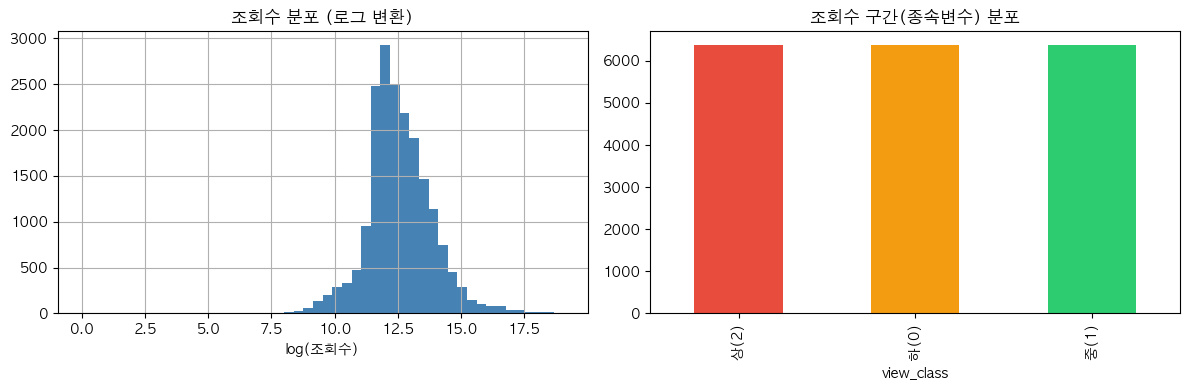

In [ ]:
df_ml = agg.dropna(subset=['view_count','like_count','comment_count',
                            'days_to_trend','publish_weekday','publish_hour']).copy()

df_ml['view_class'], bins = pd.qcut(df_ml['view_count'], q=3,
                                     labels=['하(0)','중(1)','상(2)'], retbins=True)
print(f'하(0): ~ {bins[1]:,.0f}회')
print(f'중(1): {bins[1]:,.0f} ~ {bins[2]:,.0f}회')
print(f'상(2): {bins[2]:,.0f}회 ~')
print(df_ml['view_class'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_ml['view_count'].apply(np.log1p).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('조회수 분포 (로그 변환)')
axes[0].set_xlabel('log(조회수)')
df_ml['view_class'].value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#2ecc71'])
axes[1].set_title('조회수 구간(종속변수) 분포')
plt.tight_layout()
plt.show()

## STEP 7. 학습/테스트 분리

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

FEATURES = [
    'title_length', 'tag_count', 'like_ratio', 'comment_ratio',
    'days_to_trend', 'trending_days', 'publish_weekday', 'publish_hour', 'is_korean',
]

le = LabelEncoder()
df_ml['label'] = le.fit_transform(df_ml['view_class'])

X = df_ml[FEATURES].fillna(0)
y = df_ml['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'학습: {len(X_train):,}행 / 테스트: {len(X_test):,}행')
print(f'클래스: {le.classes_}')

학습: 15,303행 / 테스트: 3,826행
클래스: ['상(2)' '중(1)' '하(0)']


## STEP 10. 하이퍼 파라미터 최적화 (GridSearchCV)

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='f1_macro', verbose=1
)
grid.fit(X_train, y_train)

print('최적 파라미터:', grid.best_params_)
print('CV F1(macro):', round(grid.best_score_, 4))

best_rf = grid.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
print(f'최적화 후 Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'최적화 후 F1(macro): {f1_score(y_test, y_pred_tuned, average="macro"):.4f}')

Fitting 3 folds for each of 27 candidates, totalling 81 fits
최적 파라미터: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
CV F1(macro): 0.6226
최적화 후 Accuracy : 0.6357
최적화 후 F1(macro): 0.6256


## STEP 13. 개선 모델 — 피처 추가 + GradientBoosting
기존 모델(랜덤 포레스트, 9개 피처)과 비교하기 위해 새 그래프를 `fig_v2_*.png`로 별도 저장합니다.

In [19]:
df_ml['log_channel_avg'] = agg.set_index('video_id').loc[df_ml['video_id'], 'log_channel_avg'].values

FEATURES_V2 = [
    'title_length', 'tag_count', 'like_ratio', 'comment_ratio',
    'days_to_trend', 'trending_days', 'publish_weekday', 'publish_hour', 'is_korean',
    'best_rank', 'log_channel_avg',
]

X_v2 = df_ml[FEATURES_V2].fillna(0)
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state=42, stratify=y
)
print(f'기존 피처: 9개 → 개선 피처: {len(FEATURES_V2)}개')
print(f'추가된 피처: best_rank, log_channel_avg')
print(f'※ like_count/comment_count 원시값은 데이터 누수로 제외')

기존 피처: 9개 → 개선 피처: 11개
추가된 피처: best_rank, log_channel_avg
※ like_count/comment_count 원시값은 데이터 누수로 제외


In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42,
)
gb_model.fit(X_train_v2, y_train_v2)
y_pred_gb = gb_model.predict(X_test_v2)

acc_gb = accuracy_score(y_test_v2, y_pred_gb)
f1_gb  = f1_score(y_test_v2, y_pred_gb, average='macro')
print(f'[개선] GradientBoosting  Accuracy={acc_gb:.4f}  F1={f1_gb:.4f}')

acc_rf = accuracy_score(y_test, best_rf.predict(X_test))
f1_rf  = f1_score(y_test, best_rf.predict(X_test), average='macro')
print(f'[기존] 랜덤 포레스트      Accuracy={acc_rf:.4f}  F1={f1_rf:.4f}')

[개선] GradientBoosting  Accuracy=0.8035  F1=0.8035
[기존] 랜덤 포레스트      Accuracy=0.6357  F1=0.6256


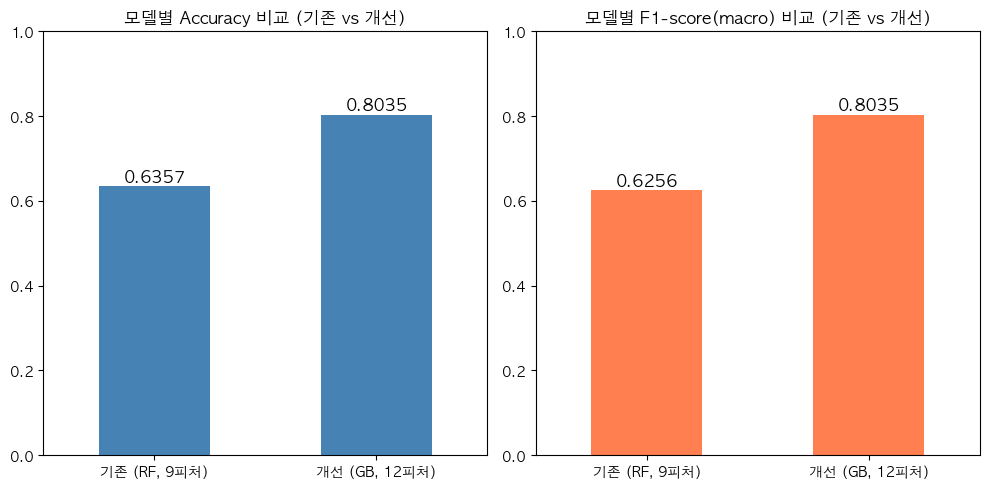

fig_v2_1_model_comparison.png 저장 완료


In [ ]:
compare_df = pd.DataFrame({
    '기존 (RF, 9피처)':        {'Accuracy': acc_rf, 'F1-score(macro)': f1_rf},
    '개선 (GB, 12피처)':       {'Accuracy': acc_gb, 'F1-score(macro)': f1_gb},
}).T

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, col, color in zip(axes, ['Accuracy', 'F1-score(macro)'], ['steelblue', 'coral']):
    compare_df[col].plot(kind='bar', ax=ax, color=color, rot=0)
    ax.set_title(f'모델별 {col} 비교 (기존 vs 개선)')
    ax.set_ylim(0, 1)
    for i, v in enumerate(compare_df[col]):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()
print('fig_v2_1_model_comparison.png 저장 완료')

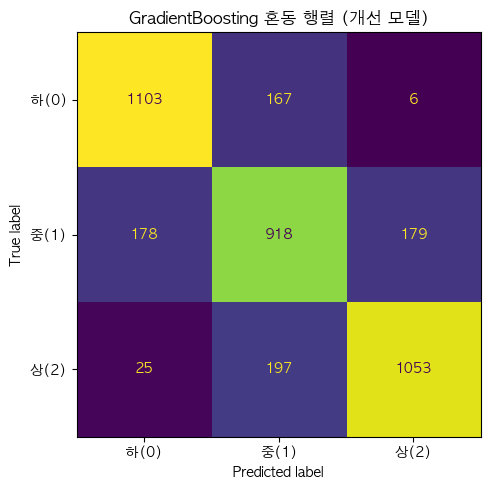

fig_v2_2_confusion_matrix.png 저장 완료


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    gb_model, X_test_v2, y_test_v2,
    display_labels=['하(0)', '중(1)', '상(2)'], colorbar=False, ax=ax
)
ax.set_title('GradientBoosting 혼동 행렬 (개선 모델)')
plt.tight_layout()
plt.savefig('/Users/eunseoklee/Downloads/fig_v2_2_confusion_matrix.png', dpi=150)
plt.show()

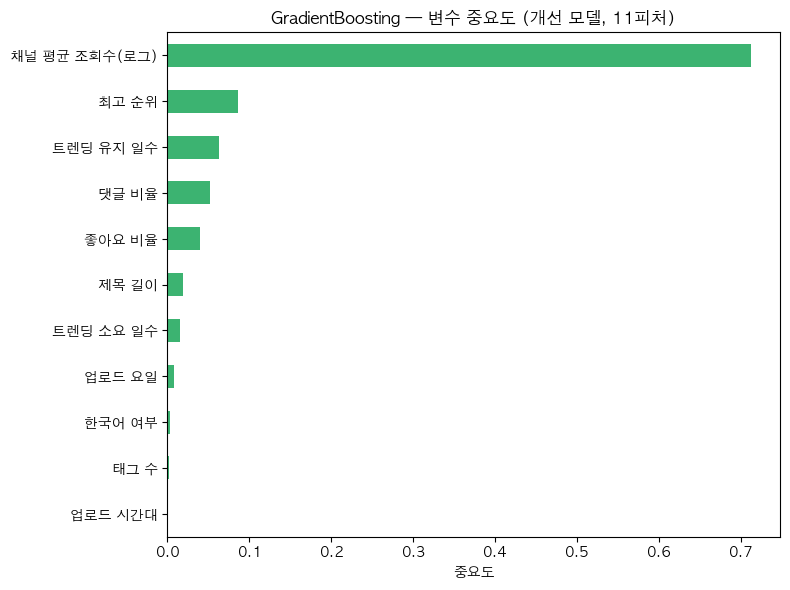

fig_v2_3_feature_importance.png 저장 완료


In [ ]:
feat_labels_v2 = {
    'title_length': '제목 길이', 'tag_count': '태그 수',
    'like_ratio': '좋아요 비율', 'comment_ratio': '댓글 비율',
    'days_to_trend': '트렌딩 소요 일수', 'trending_days': '트렌딩 유지 일수',
    'publish_weekday': '업로드 요일', 'publish_hour': '업로드 시간대',
    'is_korean': '한국어 여부', 'best_rank': '최고 순위',
    'log_channel_avg': '채널 평균 조회수(로그)',
}
feat_imp_v2 = pd.Series(gb_model.feature_importances_, index=FEATURES_V2).sort_values(ascending=True)
feat_imp_v2.index = [feat_labels_v2[i] for i in feat_imp_v2.index]

plt.figure(figsize=(8, 6))
feat_imp_v2.plot(kind='barh', color='mediumseagreen')
plt.title('GradientBoosting — 변수 중요도 (개선 모델, 11피처)')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()


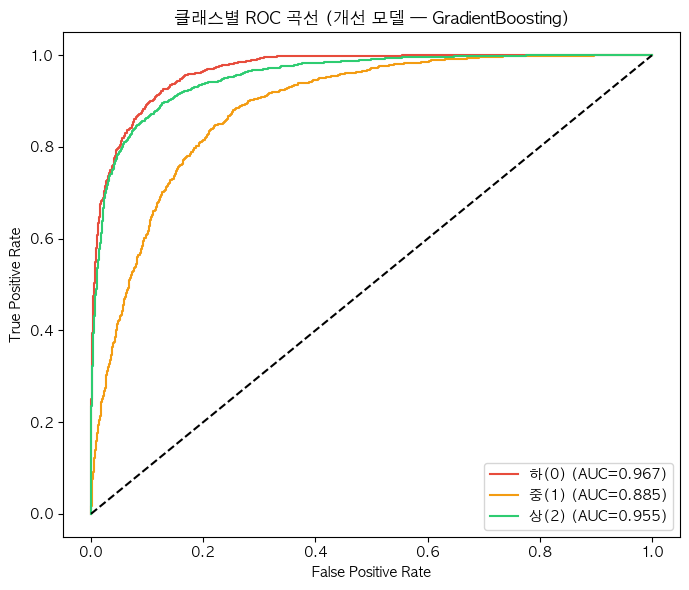

fig_v2_4_roc_curve.png 저장 완료


In [ ]:
y_test_bin_v2 = label_binarize(y_test_v2, classes=[0, 1, 2])
y_score_v2    = gb_model.predict_proba(X_test_v2)

plt.figure(figsize=(7, 6))
for i, (name, color) in enumerate(zip(['하(0)', '중(1)', '상(2)'],
                                       ['#e74c3c', '#f39c12', '#2ecc71'])):
    fpr, tpr, _ = roc_curve(y_test_bin_v2[:, i], y_score_v2[:, i])
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('클래스별 ROC 곡선 (개선 모델 — GradientBoosting)')
plt.legend()
plt.tight_layout()
plt.show()


## STEP 14. XGBoost — 추가 성능 향상 시도
GradientBoosting과 동일한 12개 피처로 XGBoost를 학습하고,
세 모델(RF / GradientBoosting / XGBoost)을 비교합니다.
새 그래프를 `fig_v3_*.png`로 별도 저장합니다.

In [25]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0,
)
xgb_model.fit(X_train_v2, y_train_v2)
y_pred_xgb = xgb_model.predict(X_test_v2)

acc_xgb = accuracy_score(y_test_v2, y_pred_xgb)
f1_xgb  = f1_score(y_test_v2, y_pred_xgb, average='macro')
print(f'[XGBoost]          Accuracy={acc_xgb:.4f}  F1={f1_xgb:.4f}')
print(f'[GradientBoosting] Accuracy={acc_gb:.4f}   F1={f1_gb:.4f}')
print(f'[랜덤 포레스트]    Accuracy={acc_rf:.4f}   F1={f1_rf:.4f}')

[XGBoost]          Accuracy=0.8032  F1=0.8032
[GradientBoosting] Accuracy=0.8035   F1=0.8035
[랜덤 포레스트]    Accuracy=0.6357   F1=0.6256


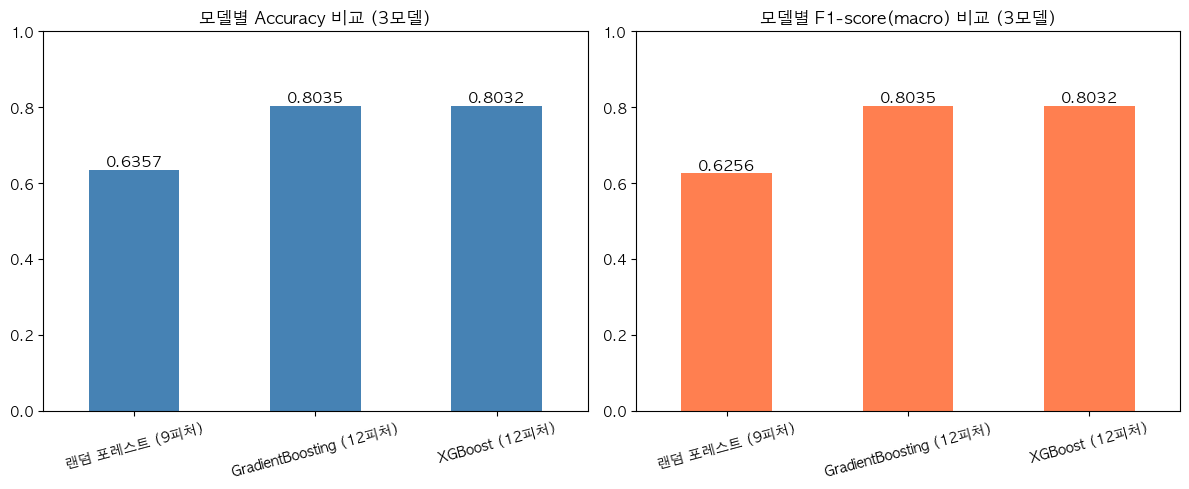

fig_v3_1_model_comparison.png 저장 완료


In [ ]:
compare3_df = pd.DataFrame({
    '랜덤 포레스트 (9피처)':      {'Accuracy': acc_rf,  'F1-score(macro)': f1_rf},
    'GradientBoosting (12피처)': {'Accuracy': acc_gb,  'F1-score(macro)': f1_gb},
    'XGBoost (12피처)':          {'Accuracy': acc_xgb, 'F1-score(macro)': f1_xgb},
}).T

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, color in zip(axes, ['Accuracy', 'F1-score(macro)'], ['steelblue', 'coral']):
    compare3_df[col].plot(kind='bar', ax=ax, color=color, rot=15)
    ax.set_title(f'모델별 {col} 비교 (3모델)')
    ax.set_ylim(0, 1)
    for i, v in enumerate(compare3_df[col]):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

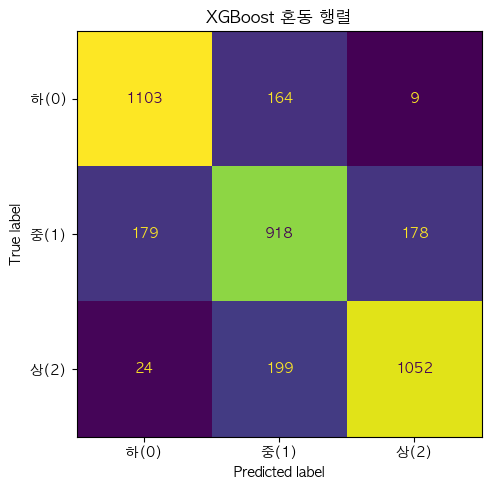

fig_v3_2_confusion_matrix.png 저장 완료


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_test_v2, y_test_v2,
    display_labels=['하(0)', '중(1)', '상(2)'], colorbar=False, ax=ax
)
ax.set_title('XGBoost 혼동 행렬')
plt.tight_layout()
plt.show()

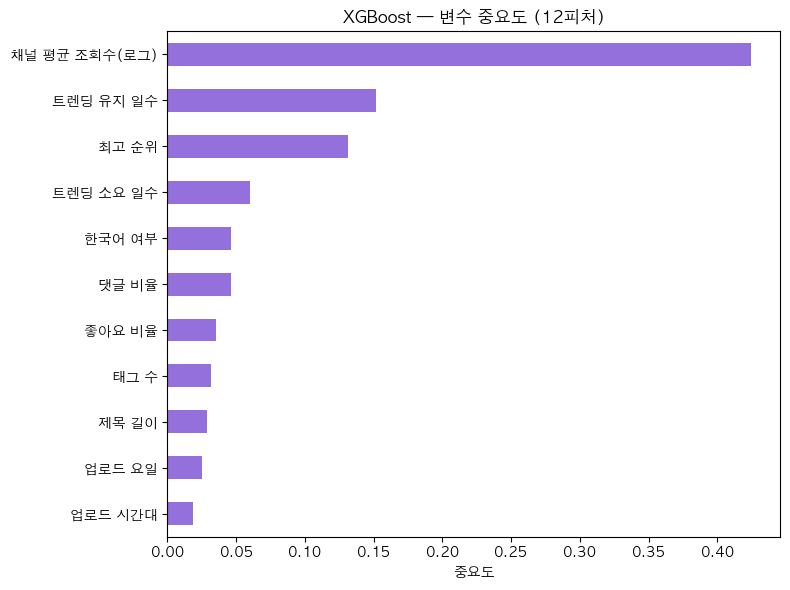

fig_v3_3_feature_importance.png 저장 완료


In [ ]:
feat_imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES_V2).sort_values(ascending=True)
feat_imp_xgb.index = [feat_labels_v2[i] for i in feat_imp_xgb.index]

plt.figure(figsize=(8, 6))
feat_imp_xgb.plot(kind='barh', color='mediumpurple')
plt.title('XGBoost — 변수 중요도 (12피처)')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

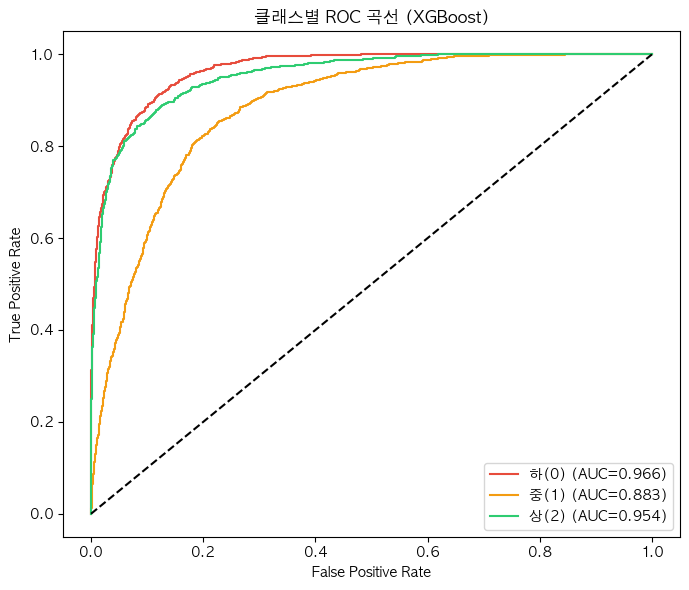

fig_v3_4_roc_curve.png 저장 완료


In [ ]:
y_score_xgb = xgb_model.predict_proba(X_test_v2)

plt.figure(figsize=(7, 6))
for i, (name, color) in enumerate(zip(['하(0)', '중(1)', '상(2)'],
                                       ['#e74c3c', '#f39c12', '#2ecc71'])):
    fpr, tpr, _ = roc_curve(y_test_bin_v2[:, i], y_score_xgb[:, i])
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('클래스별 ROC 곡선 (XGBoost)')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
print('=== XGBoost Classification Report ===')
print(classification_report(y_test_v2, y_pred_xgb, target_names=['하(0)', '중(1)', '상(2)']))

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

        하(0)       0.84      0.86      0.85      1276
        중(1)       0.72      0.72      0.72      1275
        상(2)       0.85      0.83      0.84      1275

    accuracy                           0.80      3826
   macro avg       0.80      0.80      0.80      3826
weighted avg       0.80      0.80      0.80      3826

